# <p style="color: deeppink;">Diamond dataset</p>
In this project we are given a dataset of 53940 diamonds with their info, and we need to find out and create the best model to predict the price of a diamond.
In order to achieve it we need to perform data wrangling, feature engineering and so on.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score, root_mean_squared_error

In [2]:
data = pd.read_csv('diamonds.csv')
data.head(10)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,6,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
6,7,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
7,8,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
8,9,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
9,10,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


In [3]:
print(f'Rows: {data.shape[0]}')
print(f'Features: {data.shape[1]}')

Rows: 53940
Features: 11


In [4]:
data.drop(['Unnamed: 0'], axis=1, inplace = True)

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB


In [6]:
data.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [7]:
print(data[(data['x']==0) | (data['y']==0) | (data['z']==0)])
print(100*"_")
print(data[data['y'] > 20])
print(100*"_")
print(data[data['z'] > 20]) 

       carat        cut color clarity  depth  table  price     x     y    z
2207    1.00    Premium     G     SI2   59.1   59.0   3142  6.55  6.48  0.0
2314    1.01    Premium     H      I1   58.1   59.0   3167  6.66  6.60  0.0
4791    1.10    Premium     G     SI2   63.0   59.0   3696  6.50  6.47  0.0
5471    1.01    Premium     F     SI2   59.2   58.0   3837  6.50  6.47  0.0
10167   1.50       Good     G      I1   64.0   61.0   4731  7.15  7.04  0.0
11182   1.07      Ideal     F     SI2   61.6   56.0   4954  0.00  6.62  0.0
11963   1.00  Very Good     H     VS2   63.3   53.0   5139  0.00  0.00  0.0
13601   1.15      Ideal     G     VS2   59.2   56.0   5564  6.88  6.83  0.0
15951   1.14       Fair     G     VS1   57.5   67.0   6381  0.00  0.00  0.0
24394   2.18    Premium     H     SI2   59.4   61.0  12631  8.49  8.45  0.0
24520   1.56      Ideal     G     VS2   62.2   54.0  12800  0.00  0.00  0.0
26123   2.25    Premium     I     SI1   61.3   58.0  15397  8.52  8.42  0.0
26243   1.20

In [8]:
data = data[~((data['x'] == 0) | (data['y'] == 0) | (data['z'] == 0))]

In [9]:
def remove_outliers(df, column_name):
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[column_name]>= Q1 - 1.5*IQR)&(df[column_name]<= Q3 + 1.5*IQR)]

In [10]:
data = remove_outliers(data, 'carat')
data = remove_outliers(data, 'price')

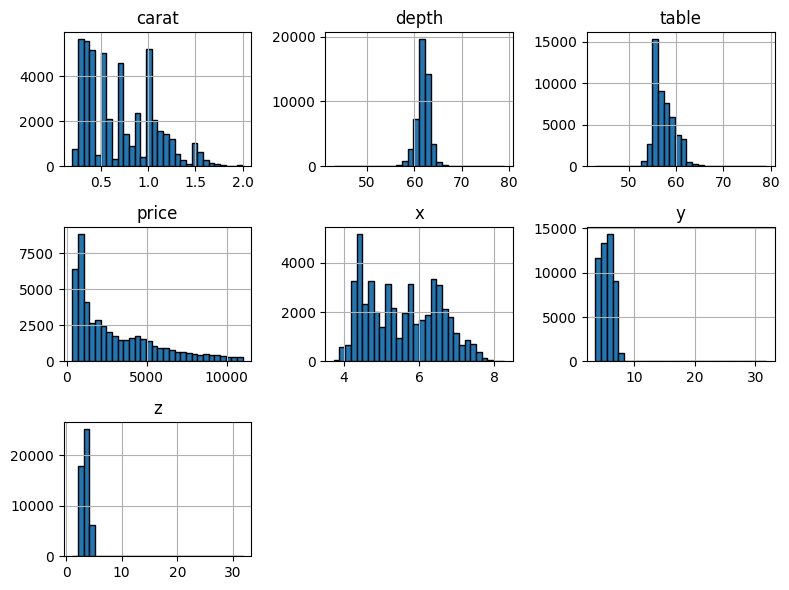

In [11]:
data.hist(bins = 30, edgecolor = 'black', figsize = (8,6))
plt.tight_layout()

 As we have ordinal categorical features in out dataset I will make them numerical, in order for the model to evaluate these as well. You can see the definitions of those features below.<br>
<u>'cut'</u> - Describe cut quality of the diamond. Quality in increasing order Fair, Good, Very Good, Premium, Ideal <br>
<u>'color'</u> - Color of the diamond, with D being the best and J the worst <br>
<u>'clarity'</u> - How obvious inclusions are within the diamond:(in order from best to worst I3 → I2 → I1 → SI2 → SI1 → VS2 → VS1 → VVS2 → VVS1 → IF → FL, FL standing for Flawless)

In [12]:
a = data.cut.value_counts()
d = {}
for i,v in enumerate(a.keys()[::-1]):
    d[v] = i
d

{'Fair': 0, 'Good': 1, 'Very Good': 2, 'Premium': 3, 'Ideal': 4}

In [13]:
data.cut = data.cut.map(d)

In [14]:
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,4,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [15]:
b = data.color.value_counts()
b

color
G    10365
E     9323
F     8888
H     7435
D     6449
I     4663
J     2378
Name: count, dtype: int64

In [16]:
color_order = ['J','I','H','G','F','E','D']
data.color = data.color.map({v:i for i,v in enumerate(color_order)})

In [17]:
c = data.clarity.value_counts()
print(c)
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
data.clarity = data.clarity.map({v: i for i, v in enumerate(clarity_order)})

clarity
SI1     12069
VS2     11258
SI2      8044
VS1      7598
VVS2     4757
VVS1     3479
IF       1657
I1        639
Name: count, dtype: int64


***Definitions of x, y, z*** <br>
x - length mm <br>
y - width mm <br>
z - depth mm <br>

In [18]:
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,4,5,1,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,5,2,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,5,4,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,1,3,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,0,1,63.3,58.0,335,4.34,4.35,2.75


<Axes: >

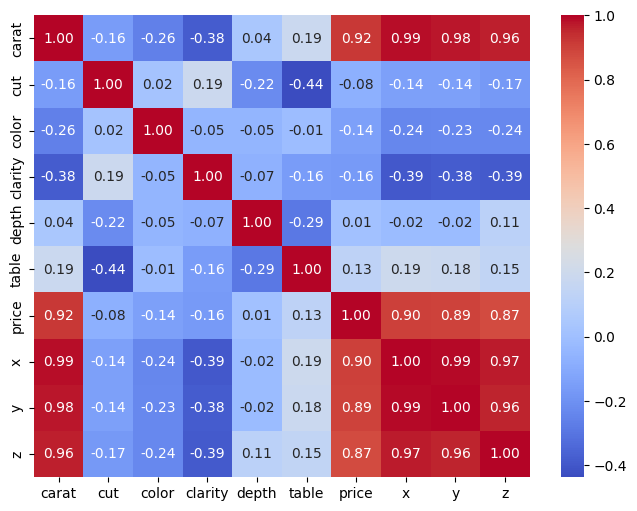

In [19]:
plt.figure(figsize = (8,6))
sns.heatmap(data.corr(), annot = True, fmt = '.2f', cmap = 'coolwarm')

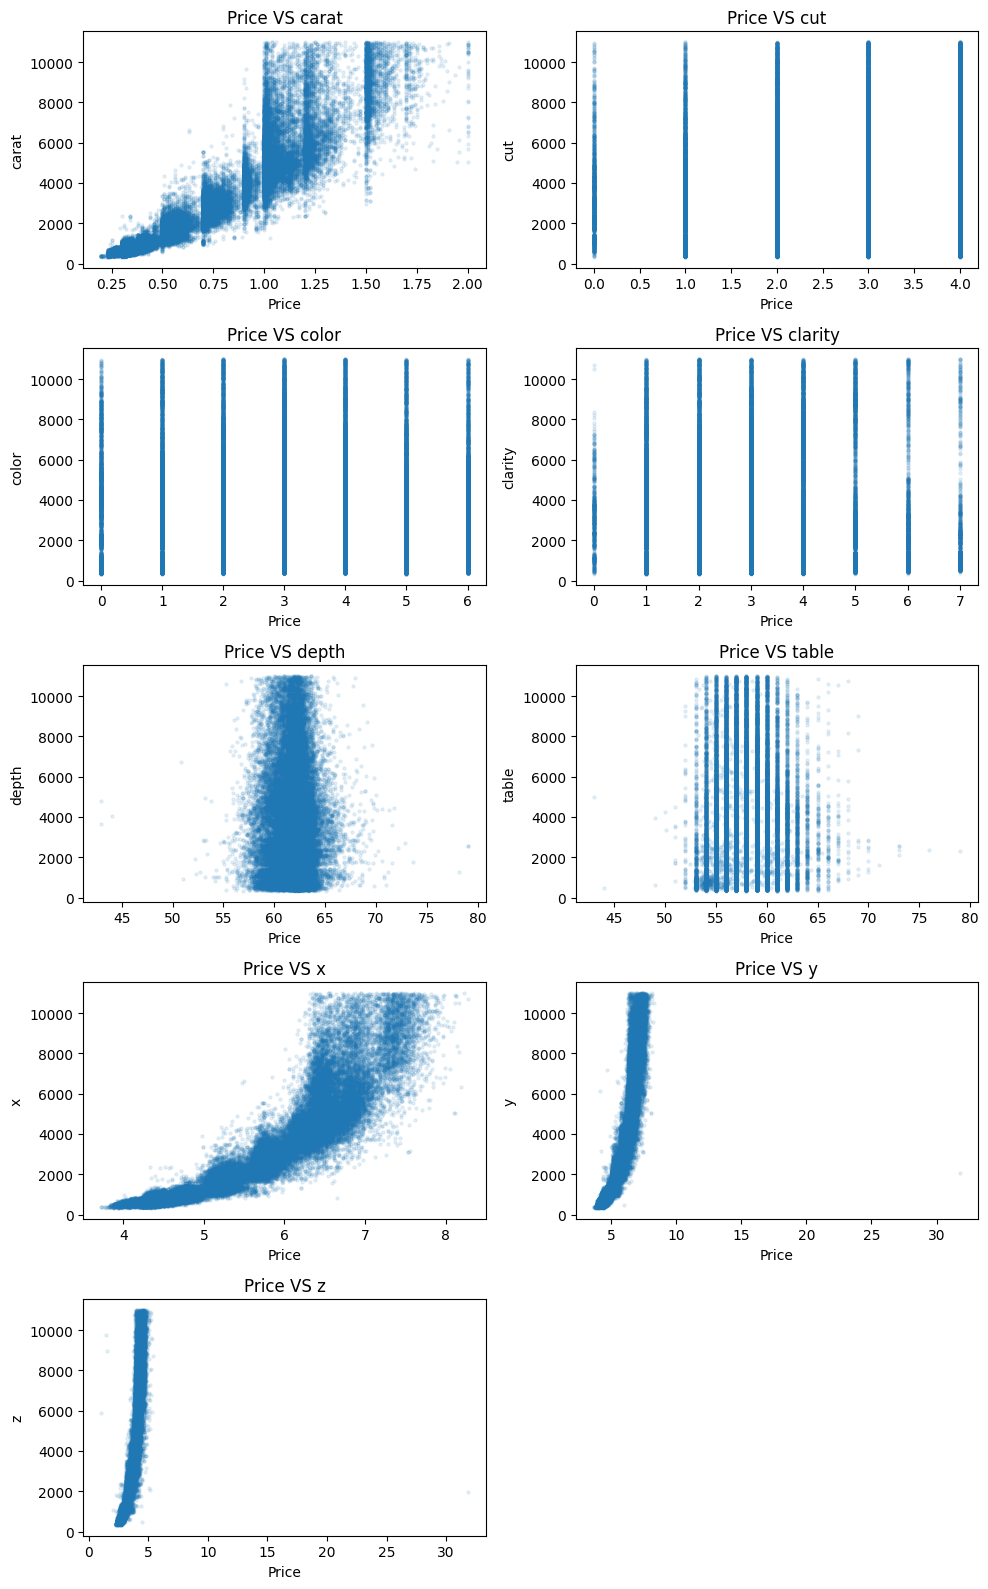

In [20]:
import math
features = data.drop('price',axis=1).columns
fig, ax = plt.subplots(math.ceil(len(features)/2),2, figsize = (10,16))
ax = ax.flatten()
for i, f in enumerate(features):
    ax[i].scatter(data[f], data['price'], alpha = 0.1, s=5)
    ax[i].set_title(f"Price VS {f}")
    ax[i].set_xlabel("Price")
    ax[i].set_ylabel(f)
for i in range(len(features), len(ax)):
    plt.delaxes(ax[i])
plt.tight_layout()


## EDA
Now, let's analyze the correlations and colinearity in our dataset. 
1. Looking at the heatmap and the plots in cell above, we can see that our target is heavily dependent on x, y, z (positive correlations of 0.88, 0.87, 0.86) and carat (corr ~0.92). Other features have somewhat no effect on our target (|correlation|<0.15).
2. The features x, y, z and carat have interchangeably very strong colinearity. As I'm going to use linear regression in this project, having collinear features becomes a problem, as coefficients become very unstable.
To avoid this let's do feature engineering and combine x,y,z into one feature => the volume. Additionally, I'll drop 'carat' column as volume has very high correlation to it, which means theyr'e essentially the same thing.

In [21]:
data['volume'] = data['x'] * data['y'] * data['z']
data.drop(['x','y','z'],axis=1, inplace = True)
data.drop('carat', axis=1, inplace=True)
data = remove_outliers(data, 'volume')

In [22]:
data.head(10)

,cut,color,clarity,depth,table,price,volume
0,4,5,1,61.5,55.0,326,38.202030
1,3,5,2,59.8,61.0,326,34.505856
2,1,5,4,56.9,65.0,327,38.076885
3,3,1,3,62.4,58.0,334,46.724580
4,1,0,1,63.3,58.0,335,51.917250
5,2,0,5,62.8,57.0,336,38.693952
6,2,1,6,62.3,57.0,336,38.830870
7,2,2,2,61.9,55.0,337,42.321081
8,0,5,3,65.1,61.0,337,36.425214
9,2,2,4,59.4,61.0,338,38.718000


In [23]:
x = data.drop('price', axis = 1).values
y = data['price'].values
print(x.shape)
print(y.shape)

(49474, 6)
(49474,)


In [24]:
class DimensionError(Exception):
    pass
class FitError(Exception):
    pass
class MyLinearRegression:
    def __init__(self):
        self.w = None
        self.b = 0
        self.cost = []
        self.fitted = False
        self.x, self.y = None, None
    def fit(self, x, y):
        if x.shape[0]!=y.shape[0]:
            raise DimensionError('Training examples and Target should have the same number of rows')
        if len(y.shape)>1:
            raise DimensionError('Target must have single column')
        self.x = x
        self.y = y
        self.fitted = True
    def normal_equation(self, return_intercept = False):
        if not self.fitted:
            raise FitError('Must first use fit method on the model')
        x = self.x
        y = self.y.reshape(-1,1)
        if return_intercept:
            x = np.concatenate((np.ones((x.shape[0],1)), x),axis=1)
        res = np.linalg.inv(x.T@x)@x.T@y
        if return_intercept:
            return res[0],res[1:]
        return res
    def gradient_descent(self, iters = 501, alpha=0.1, show_cost = False, return_coefs = False):
        if not self.fitted:
            raise FitError('Must first use fit method on the model')
        self.cost = []
        x = self.x
        y = self.y.reshape(-1,1)
        m, n = x.shape
        self.w = np.zeros((n,1))
        for i in range(iters):
            y_pr = x@self.w + self.b
            error = y - y_pr
            self.cost.append((error**2).mean())
            d_dw = -1/m * (x.T@error)
            d_db = -1/m * error.sum()
            self.w -= alpha * d_dw
            self.b -= alpha * d_db
            if show_cost and i%100==0:
                print(f"Cost at iteration {i}: {(error**2).mean()}")
        if return_coefs:
            print(f'Coefficients: {self.w}\nIntercept:{self.b}')
    def display_cost(self):
        plt.plot(self.cost, color = 'red')
        plt.title('Cost function')
        plt.xlabel('Iterations')
        plt.ylabel('Cost')
        plt.show()
    def normal_predict(self,x):
        b, w = self.normal_equation(return_intercept=True)
        return x@w + b
    def grad_predict(self, x):
        if not self.fitted:
            raise FitError('Must first use fit method on the model')
        if self.w is None:
            raise FitError('Must run gradient_descent before predicting')
        return x@self.w + self.b            
                
        

In [25]:
cv = KFold(n_splits=10, shuffle=True, random_state=0)
r2_scores = []
rmse_scores = []

for train_index, test_index in cv.split(x):
    x_train, y_train = x[train_index], y[train_index]
    x_test, y_test = x[test_index], y[test_index]
    x_train_sc = (x_train - x_train.mean(axis=0)) / x_train.std(axis=0)
    x_test_sc = (x_test - x_train.mean(axis=0)) / x_train.std(axis=0)
    model = MyLinearRegression()
    model.fit(x_train_sc, y_train)
    b, w = model.normal_equation(return_intercept=True)
    y_pr = x_test_sc @ w + b.flatten()
    y_test_actual = y_test
    r2_scores.append(r2_score(y_test_actual, y_pr))
    rmse_scores.append(root_mean_squared_error(y_test_actual, y_pr))

print(f"R²:   {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
print(f"RMSE: {np.mean(rmse_scores):.2f} ± {np.std(rmse_scores):.2f}")

R²:   0.9095 ± 0.0021
RMSE: 773.66 ± 9.64


In [27]:
def plotting(y, y_pr):
    plt.plot(np.sort(y), np.sort(y), color='red', linestyle='--', alpha=0.7, label='Perfect Accuracy')
    plt.scatter(y, y_pr, alpha=0.2, s=5, label='Prediction')
    plt.xlabel('Actual')
    plt.ylabel('Prediction')
    plt.title('Prediction Accuracy')
    plt.legend()
    plt.show()

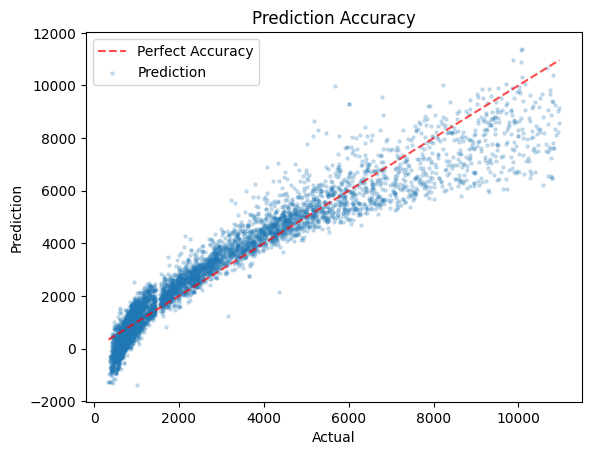

In [28]:
plotting(y_test, y_pr)

## Conclusion
We built a linear regression model from scratch to predict diamond prices. After removing invalid 
rows, engineering a volume feature from x/y/z dimensions, and dropping carat due to redundancy, 
the model achieved R² = 0.91 ± 0.002 and RMSE = 773 ± 9.6 via 10-fold cross-validation. 
And I also tried to implement logarithmic function based on the theory that
The diamond price increases disproportionally with the carat size, so if we just fit a straight line in the model, the model will underrate expensive diamonds. So let's do a neat trick without using polynomial regression. I'll do logarithm function e.g. ln(x), (base = e) on price column, so the prediction model will look like log(price) = w_caratx1 + w_cutx2 + ... + b. The pure price will be price = exp(w_caratx1 + w_cutx2 + ... + b), which is an increasing function on all its x domain and is convex. But the results were half of what we've achieved here. So theory does not always work as excpected in practice.